In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from utils import postprocess_and_compute_distance, compute_motion_metrics, compute_extended_hand_metrics,compute_bimanual_dexterity

In [58]:
dfs30fps = [df for df in os.listdir("output_dataframes") if df.endswith("30fps.pkl")]
dfs10fps = [df.replace("30fps", "10fps") for df in dfs30fps]
dfs = list(zip(dfs30fps, dfs10fps))
dfs

[('hand_tracking_2024-01-24_16-52-58_30fps.pkl',
  'hand_tracking_2024-01-24_16-52-58_10fps.pkl'),
 ('hand_tracking_2024-01-24_17-19-03_30fps.pkl',
  'hand_tracking_2024-01-24_17-19-03_10fps.pkl'),
 ('hand_tracking_2024-01-24_09-56-13_30fps.pkl',
  'hand_tracking_2024-01-24_09-56-13_10fps.pkl'),
 ('hand_tracking_2024-01-15_13-37-36_30fps.pkl',
  'hand_tracking_2024-01-15_13-37-36_10fps.pkl'),
 ('hand_tracking_2024-01-18_17-08-23_30fps.pkl',
  'hand_tracking_2024-01-18_17-08-23_10fps.pkl'),
 ('hand_tracking_2024-01-15_16-31-26_30fps.pkl',
  'hand_tracking_2024-01-15_16-31-26_10fps.pkl'),
 ('hand_tracking_2024-01-18_15-17-27_30fps.pkl',
  'hand_tracking_2024-01-18_15-17-27_10fps.pkl'),
 ('hand_tracking_2024-01-19_14-50-40_30fps.pkl',
  'hand_tracking_2024-01-19_14-50-40_10fps.pkl'),
 ('hand_tracking_2024-01-17_16-22-28_30fps.pkl',
  'hand_tracking_2024-01-17_16-22-28_10fps.pkl'),
 ('hand_tracking_2024-01-22_17-16-51_30fps.pkl',
  'hand_tracking_2024-01-22_17-16-51_10fps.pkl'),
 ('hand_tr

## SNR and PSD comparison

In [53]:
from scipy.signal import welch

# df_hand: processed per-frame dataframe at given fps
def estimate_noise_snr(df_hand, min_move_px=3, fps=30):
    df = df_hand.sort_values('frame').copy()
    df['frame_diff'] = df['frame'].diff().fillna(1)
    df['dt'] = df['frame_diff'] / fps
    df = df[df['dt']>0]
    df['velocity'] = df['disp_filtered'] / df['dt'].replace(0, np.nan)

    # find low-movement frames (idle)
    idle_mask = df['velocity'] < (min_move_px * fps)  # threshold in px/s
    noise_vel_rms = np.sqrt((df.loc[idle_mask,'velocity']**2).mean())
    signal_vel_rms = np.sqrt((df.loc[~idle_mask,'velocity']**2).mean())
    snr = signal_vel_rms / (noise_vel_rms + 1e-9)
    return {'noise_vel_rms': noise_vel_rms, 'signal_vel_rms': signal_vel_rms, 'snr': snr}

from scipy.signal import welch
def velocity_psd(df_hand, fps=30, nperseg=256):
    df = df_hand.sort_values('frame')
    df['dt'] = df['frame'].diff().fillna(1)/fps
    vel = (df['disp_filtered'] / df['dt']).fillna(0).values
    f, Pxx = welch(vel, fs=fps, nperseg=min(nperseg, len(vel)))
    return f, Pxx

SNR 30 fps: {'noise_vel_rms': 39.824044643555084, 'signal_vel_rms': 401.956766152405, 'snr': 10.093318489872734}
SNR 10 fps: {'noise_vel_rms': 13.486436998843157, 'signal_vel_rms': 114.09518395274792, 'snr': 8.459994582266228}


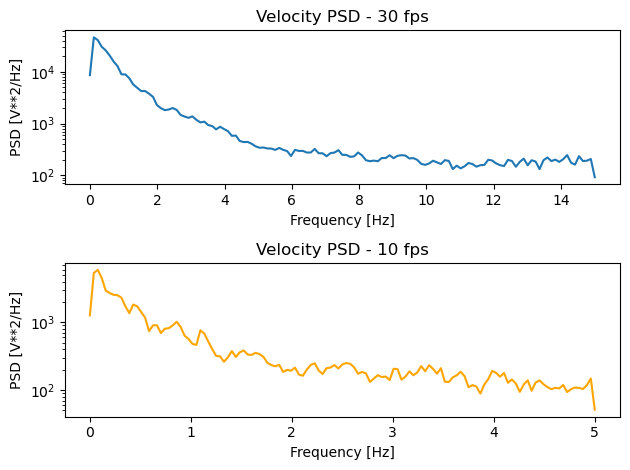

SNR 30 fps: {'noise_vel_rms': 37.08623331941636, 'signal_vel_rms': 406.21284857838145, 'snr': 10.953197782821398}
SNR 10 fps: {'noise_vel_rms': 12.797439336113028, 'signal_vel_rms': 99.00293719639663, 'snr': 7.736152099528583}


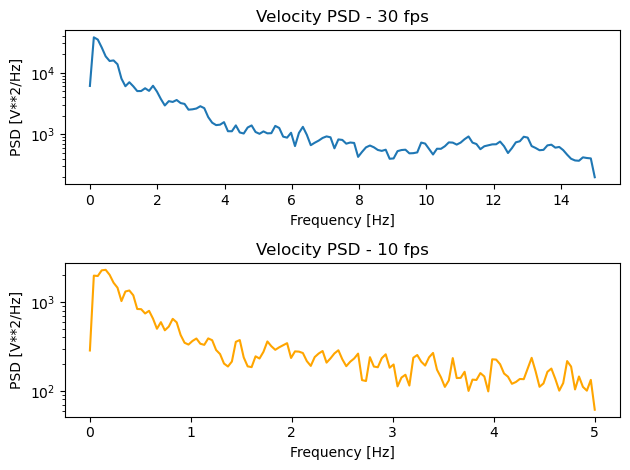

SNR 30 fps: {'noise_vel_rms': 44.829375147376396, 'signal_vel_rms': 380.2407589103048, 'snr': 8.481955361897926}
SNR 10 fps: {'noise_vel_rms': 15.579766433584302, 'signal_vel_rms': 82.91361754923078, 'snr': 5.32187808446071}


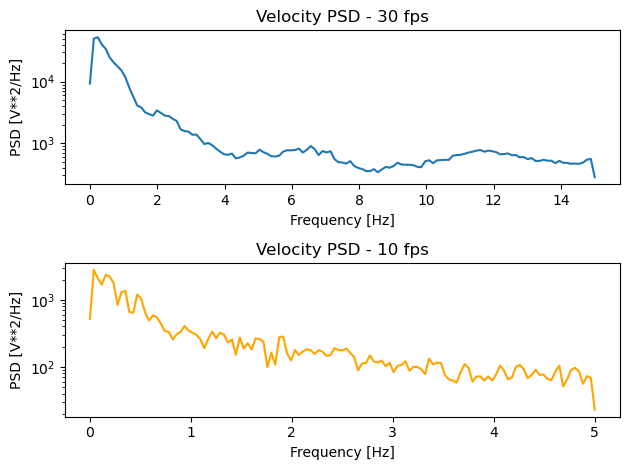

In [57]:
i = 0
for df30, df10 in dfs:
    if i == 3:
        break
    i += 1
    vid_name = df30.split('_30fps')[0]

    # Load dataframes
    df_30 = pd.read_pickle(os.path.join("output_dataframes", df30))
    df_10 = pd.read_pickle(os.path.join("output_dataframes", df10))

    # Postprocess and compute distances
    df_30 = postprocess_and_compute_distance(df_30, window=9, max_jump=85, min_disp=1.0)
    df_10 = postprocess_and_compute_distance(df_10, window=5, max_jump=250, min_disp=2.0)

    df_30_left = df_30[df_30['hand_label'] == 'Left']
    df_30_right = df_30[df_30['hand_label'] == 'Right']
    df_10_left = df_10[df_10['hand_label'] == 'Left']
    df_10_right = df_10[df_10['hand_label'] == 'Right']

    # Compute SNR
    snr_30 = estimate_noise_snr(df_30_right, fps=30)
    snr_10 = estimate_noise_snr(df_10_right, fps=10)

    print("SNR 30 fps:", snr_30)
    print("SNR 10 fps:", snr_10)
    # compute psd
    f30, Pxx30 = velocity_psd(df_30_right, fps=30)
    f10, Pxx10 = velocity_psd(df_10_right, fps=10)
    plt.figure()
    plt.subplot(2,1,1)
    plt.semilogy(f30, Pxx30, label='30 fps')
    plt.title('Velocity PSD - 30 fps')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('PSD [V**2/Hz]')
    plt.subplot(2,1,2)
    plt.semilogy(f10, Pxx10, label='10 fps', color='orange')
    plt.title('Velocity PSD - 10 fps')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('PSD [V**2/Hz]')
    plt.tight_layout()
    plt.show()

## Metrics comparison

In [21]:
dfs10fps
old_processed_10fps = [os.path.join("processed_dataframes_old", df.replace("_10fps", "processed")) for df in dfs10fps]
dfs_old_new = list(zip(dfs10fps, old_processed_10fps))
dfs_old_new

[('hand_tracking_2024-01-15_13-37-36_10fps.pkl',
  'processed_dataframes/hand_tracking_2024-01-15_13-37-36processed.pkl'),
 ('hand_tracking_2024-01-15_16-31-26_10fps.pkl',
  'processed_dataframes/hand_tracking_2024-01-15_16-31-26processed.pkl'),
 ('hand_tracking_2024-01-19_14-50-40_10fps.pkl',
  'processed_dataframes/hand_tracking_2024-01-19_14-50-40processed.pkl'),
 ('hand_tracking_2024-01-18_13-11-31_10fps.pkl',
  'processed_dataframes/hand_tracking_2024-01-18_13-11-31processed.pkl')]

In [22]:
metric_fun = compute_extended_hand_metrics
hand_label = "Right"
comparison_df = pd.DataFrame()

for df10, df10_old_processed in dfs_old_new:
    vid_name = df10.split('_10fps')[0]
    print(f"Processing {vid_name} ...")
    
    df_10 = pd.read_pickle(os.path.join("output_dataframes", df10))
    df_10 = postprocess_and_compute_distance(df_10, window=5, max_jump=250, min_disp=2.0)
    df_10_old = pd.read_pickle(df10_old_processed)

    df_10_old_left = df_10_old[df_10_old['hand_label'] == hand_label]
    df_10_left = df_10[df_10['hand_label'] == hand_label]

    # Compute extended hand metrics
    ext_metrics_10_old = metric_fun(df_10_old, hand_label=hand_label, fps=30)
    ext_metrics_10 = metric_fun(df_10, hand_label=hand_label, fps=30)

    # Convert the single-row DataFrames to dictionaries
    metrics_10_old = ext_metrics_10_old.iloc[0].to_dict()
    metrics_10 = ext_metrics_10.iloc[0].to_dict()

    # Build a combined comparison row
    row_data = {"video": vid_name}
    for key in metrics_10_old.keys():
        val_10_old = metrics_10_old[key]
        val_10 = metrics_10.get(key, np.nan)

        row_data[f"{key}_10fps_old"] = val_10_old
        row_data[f"{key}_10fps"] = val_10
        row_data[f"{key}_ratio"] = (
            val_10 / val_10_old if pd.notnull(val_10_old) and val_10_old != 0 else np.nan
        )

    # Add to comparison dataframe
    comparison_df = pd.concat([comparison_df, pd.DataFrame([row_data])], ignore_index=True)

Processing hand_tracking_2024-01-15_13-37-36...
Processing hand_tracking_2024-01-15_16-31-26...
Processing hand_tracking_2024-01-19_14-50-40...
Processing hand_tracking_2024-01-18_13-11-31...


In [23]:
comparison_df 

,video,total_path_right_10fps_old,total_path_right_10fps,total_path_right_ratio,total_duration_right_10fps_old,total_duration_right_10fps,total_duration_right_ratio,mean_velocity_right_10fps_old,mean_velocity_right_10fps,mean_velocity_right_ratio,...,tremor_rms_right_ratio,mean_abs_angle_change_right_10fps_old,mean_abs_angle_change_right_10fps,mean_abs_angle_change_right_ratio,num_reversals_right_10fps_old,num_reversals_right_10fps,num_reversals_right_ratio,intermittency_ratio_right_10fps_old,intermittency_ratio_right_10fps,intermittency_ratio_right_ratio
0,hand_tracking_2024-01-15_13-37-36,48645.223825,37709.726200,0.775199,287.833333,287.833333,1.0,124.896323,101.143293,0.809818,...,NaN,2.609155,2.629873,1.007940,1655.0,1644.0,0.993353,0.563066,0.548755,0.974583
1,hand_tracking_2024-01-15_16-31-26,60099.316607,57707.922736,0.960209,347.133333,347.133333,1.0,134.704862,131.081242,0.973100,...,NaN,2.246989,2.266706,1.008775,1881.0,1886.0,1.002658,0.568436,0.571883,1.006065
2,hand_tracking_2024-01-19_14-50-40,35278.804662,31345.311638,0.888503,346.233333,346.233333,1.0,88.046472,82.147221,0.932998,...,1.002574,2.278695,2.261216,0.992330,1111.0,1123.0,1.010801,0.406951,0.407645,1.001705
3,hand_tracking_2024-01-18_13-11-31,59432.691642,57010.225493,0.959240,392.033333,392.033333,1.0,118.090440,113.898171,0.964500,...,NaN,2.517905,2.526444,1.003391,2157.0,2167.0,1.004636,0.561339,0.564654,1.005906


In [104]:
metric_fun = compute_extended_hand_metrics
hand_label = "Right"
comparison_df = pd.DataFrame()

for df30_name, df10_name in dfs:
    vid_name = df30_name.split('_30fps')[0]
    print(f"Processing {vid_name} ...")
    
    # Postprocess and compute distances

    # first check if already processed
    if df30_name.split('.')[0] + "_processed.pkl" in os.listdir("processed_dataframes"):
        print(f"  Skipping postprocessing for {vid_name}, already processed.")
        df_30 = pd.read_pickle(os.path.join("processed_dataframes", df30_name.split('.')[0] + "_processed.pkl"))
    else:
        df_30 = pd.read_pickle(os.path.join("output_dataframes", df30_name))
        df_30 = postprocess_and_compute_distance(df_30, window=9, max_jump=85, min_disp=1.0)
        # save processed
        df_30.to_pickle(os.path.join("processed_dataframes", df30_name.split('.')[0] + "_processed.pkl"))
        
    if df10_name.split('.')[0] + "_processed.pkl" in os.listdir("processed_dataframes"):
        print(f"  Skipping postprocessing for {vid_name}, already processed.")
        df_10 = pd.read_pickle(os.path.join("processed_dataframes", df10_name.split('.')[0] + "_processed.pkl"))
    else:
        df_10 = pd.read_pickle(os.path.join("output_dataframes", df10_name))
        df_10 = postprocess_and_compute_distance(df_10, window=5, max_jump=250, min_disp=2.0)
        # save processed
        df_10.to_pickle(os.path.join("processed_dataframes", df10_name.split('.')[0] + "_processed.pkl"))

    df_30 = df_30[df_30['hand_label'] == hand_label]
    df_10 = df_10[df_10['hand_label'] == hand_label]
    # Compute extended hand metrics
    ext_metrics_30 = metric_fun(df_30, hand_label=hand_label, fps=30)
    ext_metrics_10 = metric_fun(df_10, hand_label=hand_label, fps=30)

    # Convert the single-row DataFrames to dictionaries
    metrics_30 = ext_metrics_30.iloc[0].to_dict()
    metrics_10 = ext_metrics_10.iloc[0].to_dict()

    # Build a combined comparison row
    row_data = {"video": vid_name}
    for key in metrics_30.keys():
        val_30 = metrics_30[key]
        val_10 = metrics_10.get(key, np.nan)

        row_data[f"{key}_30fps"] = val_30
        row_data[f"{key}_10fps"] = val_10
        row_data[f"{key}_ratio"] = (
            val_10 / val_30 if pd.notnull(val_30) and val_30 != 0 else np.nan
        )

    # Add to comparison dataframe
    comparison_df = pd.concat([comparison_df, pd.DataFrame([row_data])], ignore_index=True)


Processing hand_tracking_2024-01-24_16-52-58 ...
  Skipping postprocessing for hand_tracking_2024-01-24_16-52-58, already processed.
  Skipping postprocessing for hand_tracking_2024-01-24_16-52-58, already processed.
Processing hand_tracking_2024-01-24_17-19-03 ...
  Skipping postprocessing for hand_tracking_2024-01-24_17-19-03, already processed.
  Skipping postprocessing for hand_tracking_2024-01-24_17-19-03, already processed.
Processing hand_tracking_2024-01-24_09-56-13 ...
  Skipping postprocessing for hand_tracking_2024-01-24_09-56-13, already processed.
  Skipping postprocessing for hand_tracking_2024-01-24_09-56-13, already processed.
Processing hand_tracking_2024-01-15_13-37-36 ...
  Skipping postprocessing for hand_tracking_2024-01-15_13-37-36, already processed.
  Skipping postprocessing for hand_tracking_2024-01-15_13-37-36, already processed.
Processing hand_tracking_2024-01-18_17-08-23 ...
  Skipping postprocessing for hand_tracking_2024-01-18_17-08-23, already processed.

In [106]:
comparison_df

,video,total_path_right_30fps,total_path_right_10fps,total_path_right_ratio,total_duration_right_30fps,total_duration_right_10fps,total_duration_right_ratio,mean_velocity_right_30fps,mean_velocity_right_10fps,mean_velocity_right_ratio,...,tremor_rms_right_ratio,mean_abs_angle_change_right_30fps,mean_abs_angle_change_right_10fps,mean_abs_angle_change_right_ratio,num_reversals_right_30fps,num_reversals_right_10fps,num_reversals_right_ratio,intermittency_ratio_right_30fps,intermittency_ratio_right_10fps,intermittency_ratio_right_ratio
0,hand_tracking_2024-01-24_16-52-58,69645.880739,59106.245210,0.848668,693.800000,693.733333,0.999904,125.109663,103.292160,0.825613,...,0.522256,0.385090,0.755052,1.960715,1205.0,984.0,0.816598,0.110831,0.178611,1.611561
1,hand_tracking_2024-01-24_17-19-03,51749.989262,47245.873463,0.912964,590.333333,590.333333,1.000000,103.751878,90.974274,0.876845,...,1.322595,0.410157,0.759800,1.852459,810.0,761.0,0.939506,0.109280,0.179089,1.638804
2,hand_tracking_2024-01-24_09-56-13,54767.727915,46155.669159,0.842753,527.133333,526.933333,0.999621,125.902773,103.661755,0.823348,...,0.888186,0.363426,0.774505,2.131119,818.0,732.0,0.894866,0.119529,0.184933,1.547179
3,hand_tracking_2024-01-15_13-37-36,26230.235965,19950.827663,0.760604,287.900000,287.833333,0.999768,117.217149,90.191004,0.769435,...,NaN,0.547121,0.938191,1.714777,466.0,378.0,0.811159,0.103590,0.174413,1.683690
4,hand_tracking_2024-01-18_17-08-23,27169.757259,19168.348619,0.705503,451.366667,451.233333,0.999705,76.826426,55.780490,0.726059,...,0.693744,0.372744,0.768941,2.062920,359.0,399.0,1.111421,0.104801,0.171287,1.634407
5,hand_tracking_2024-01-15_16-31-26,42779.601156,29820.692710,0.697077,346.433333,346.333333,0.999711,165.181909,118.470648,0.717213,...,NaN,0.536681,0.970042,1.807485,621.0,455.0,0.732689,0.081168,0.123282,1.518853
6,hand_tracking_2024-01-18_15-17-27,61206.842189,46648.183735,0.762140,634.666667,634.033333,0.999002,137.928687,101.961168,0.739231,...,1.227758,0.452018,0.961363,2.126822,889.0,769.0,0.865017,0.126800,0.197619,1.558507
7,hand_tracking_2024-01-19_14-50-40,25087.472201,17961.477573,0.715954,346.200000,346.233333,1.000096,114.889833,82.481292,0.717916,...,2.620370,0.338690,0.797539,2.354777,349.0,296.0,0.848138,0.109315,0.176720,1.616607
8,hand_tracking_2024-01-17_16-22-28,60819.401667,49702.035750,0.817207,885.566667,885.533333,0.999962,81.140182,65.552865,0.807896,...,1.014650,0.355526,0.761329,2.141419,884.0,928.0,1.049774,0.112766,0.188138,1.668388
9,hand_tracking_2024-01-22_17-16-51,55197.785692,49900.272888,0.904027,604.233333,603.933333,0.999504,111.597696,99.203152,0.888935,...,0.986938,0.341850,0.678542,1.984914,900.0,794.0,0.882222,0.091837,0.153231,1.668513


In [107]:
cols = [col for col in comparison_df.columns if col.endswith('fps')]
correlations = {}

for i in range(int(len(cols)/2)):
    col_30 = cols[2*i]
    col_10 = cols[2*i + 1]
    corr = comparison_df[[col_30, col_10]].corr().iloc[0,1]
    correlations[f"{col_30} vs {col_10}"] = corr
    
correlations

{'total_path_right_30fps vs total_path_right_10fps': 0.9687769548728774,
 'total_duration_right_30fps vs total_duration_right_10fps': 0.9999991528970587,
 'mean_velocity_right_30fps vs mean_velocity_right_10fps': 0.9262388810734664,
 'rms_accel_right_30fps vs rms_accel_right_10fps': 0.4991646166960181,
 'efficiency_right_30fps vs efficiency_right_10fps': 0.8861436982485207,
 'duty_cycle_right_30fps vs duty_cycle_right_10fps': 0.9741902683101851,
 'tremor_rms_right_30fps vs tremor_rms_right_10fps': 0.8663194048197858,
 'mean_abs_angle_change_right_30fps vs mean_abs_angle_change_right_10fps': 0.8533722632991269,
 'num_reversals_right_30fps vs num_reversals_right_10fps': 0.9249414188394711,
 'intermittency_ratio_right_30fps vs intermittency_ratio_right_10fps': 0.9349639099266307}

In [35]:
cols = [col for col in comparison_df.columns if '_ratio' in col]
comparison_df[cols]

,total_path_right_ratio,total_duration_right_ratio,mean_velocity_right_ratio,rms_accel_right_ratio,efficiency_right_ratio,duty_cycle_right_ratio,tremor_rms_right_ratio,mean_abs_angle_change_right_ratio,num_reversals_right_ratio,intermittency_ratio_right_30fps,intermittency_ratio_right_10fps,intermittency_ratio_right_ratio
0,0.813630,0.999653,0.842487,0.283638,0.813913,1.083328,NaN,0.937156,0.372367,0.500610,0.548755,1.096172
1,0.739941,1.000000,0.799297,0.623740,0.739941,1.051508,NaN,0.917232,0.395471,0.513070,0.571883,1.114630
2,0.732807,1.000096,0.783100,0.729364,0.732737,1.056011,1.52493,0.883255,0.421705,0.351637,0.407645,1.159278
3,0.844872,1.000000,0.838549,0.683676,0.844872,1.060079,0.00000,0.909893,0.391438,0.516808,0.564654,1.092580


In [100]:
metric_fun = compute_extended_hand_metrics
comparison_df_bimanual = pd.DataFrame()

for df30_name, df10_name in dfs:
    vid_name = df30_name.split('_30fps')[0]
    print(f"Processing {vid_name}...")
    
    # Postprocess and compute distances
    if df30_name.split('.')[0] + "_processed.pkl" in os.listdir("processed_dataframes"):
        print(f"  Skipping postprocessing for {vid_name}, already processed.")
        df_30 = pd.read_pickle(os.path.join("processed_dataframes", df30_name.split('.')[0] + "_processed.pkl"))
    else:
        df_30 = pd.read_pickle(os.path.join("output_dataframes", df30_name))
        df_30 = postprocess_and_compute_distance(df_30, window=9, max_jump=85, min_disp=1.0)
        # save processed
        df_30.to_pickle(os.path.join("processed_dataframes", df30_name.split('.')[0] + "_processed.pkl"))

    if df10_name.split('.')[0] + "_processed.pkl" in os.listdir("processed_dataframes"):
        print(f"  Skipping postprocessing for {vid_name}, already processed.")
        df_10 = pd.read_pickle(os.path.join("processed_dataframes", df10_name.split('.')[0] + "_processed.pkl"))
    else:
        df_10 = pd.read_pickle(os.path.join("output_dataframes", df10_name))
        df_10 = postprocess_and_compute_distance(df_10, window=5, max_jump=250, min_disp=2.0)
        # save processed
        df_10.to_pickle(os.path.join("processed_dataframes", df10_name.split('.')[0] + "_processed.pkl"))

    df_30_left = df_30[df_30['hand_label'] == 'Left']
    df_30_right = df_30[df_30['hand_label'] == 'Right']
    df_10_left = df_10[df_10['hand_label'] == 'Left']
    df_10_right = df_10[df_10['hand_label'] == 'Right']

    # Compute extended hand metrics
    ext_metrics_30 = compute_bimanual_dexterity(df_30_left, df_30_right, fps=30)
    ext_metrics_10 = compute_bimanual_dexterity(df_10_left, df_10_right, fps=30)

    # Convert the single-row DataFrames to dictionaries
    metrics_30 = ext_metrics_30.iloc[0].to_dict()
    metrics_10 = ext_metrics_10.iloc[0].to_dict()

    # Build a combined comparison row
    row_data = {"video": vid_name}
    for key in metrics_30.keys():
        val_30 = metrics_30[key]
        val_10 = metrics_10.get(key, np.nan)

        row_data[f"{key}_30fps"] = val_30
        row_data[f"{key}_10fps"] = val_10
        row_data[f"{key}_ratio"] = (
            val_10 / val_30 if pd.notnull(val_30) and val_30 != 0 else np.nan
        )

    # Add to comparison dataframe
    comparison_df_bimanual = pd.concat([comparison_df_bimanual, pd.DataFrame([row_data])], ignore_index=True)


Processing hand_tracking_2024-01-24_16-52-58...
  Skipping postprocessing for hand_tracking_2024-01-24_16-52-58, already processed.
  Skipping postprocessing for hand_tracking_2024-01-24_16-52-58, already processed.
Processing hand_tracking_2024-01-24_17-19-03...
  Skipping postprocessing for hand_tracking_2024-01-24_17-19-03, already processed.
  Skipping postprocessing for hand_tracking_2024-01-24_17-19-03, already processed.
Processing hand_tracking_2024-01-24_09-56-13...
  Skipping postprocessing for hand_tracking_2024-01-24_09-56-13, already processed.
  Skipping postprocessing for hand_tracking_2024-01-24_09-56-13, already processed.
Processing hand_tracking_2024-01-15_13-37-36...
  Skipping postprocessing for hand_tracking_2024-01-15_13-37-36, already processed.
  Skipping postprocessing for hand_tracking_2024-01-15_13-37-36, already processed.
Processing hand_tracking_2024-01-18_17-08-23...
  Skipping postprocessing for hand_tracking_2024-01-18_17-08-23, already processed.
  Sk

In [101]:
comparison_df_bimanual

,video,velocity_corr_30fps,velocity_corr_10fps,velocity_corr_ratio,velocity_corr_moving_30fps,velocity_corr_moving_10fps,velocity_corr_moving_ratio,interhand_dist_mean_30fps,interhand_dist_mean_10fps,interhand_dist_mean_ratio,...,movement_overlap_ratio_ratio,interhand_dist_cv_30fps,interhand_dist_cv_10fps,interhand_dist_cv_ratio,interhand_dist_change_rms_30fps,interhand_dist_change_rms_10fps,interhand_dist_change_rms_ratio,velocity_ratio_30fps,velocity_ratio_10fps,velocity_ratio_ratio
0,hand_tracking_2024-01-24_16-52-58,0.430008,0.276962,0.644086,0.466079,0.298422,0.640281,384.248875,385.174307,1.002408,...,1.104669,0.323686,0.319164,0.986029,19.947463,42.231066,2.117115,0.836697,0.763228,0.912192
1,hand_tracking_2024-01-24_17-19-03,0.491903,0.423358,0.860653,0.497477,0.396144,0.796307,325.048713,323.052839,0.993860,...,1.077183,0.370593,0.364329,0.983099,19.239061,36.789517,1.912230,1.076631,0.965885,0.897137
2,hand_tracking_2024-01-24_09-56-13,0.404495,0.314690,0.777981,0.433658,0.384032,0.885565,386.313288,385.451006,0.997768,...,1.178561,0.263624,0.246343,0.934450,18.784267,34.765629,1.850784,0.511640,0.490102,0.957904
3,hand_tracking_2024-01-15_13-37-36,0.432973,0.455558,1.052161,0.339277,0.384481,1.133238,369.560140,368.949143,0.998347,...,1.165281,0.238186,0.230845,0.969179,20.444188,35.924647,1.757206,0.682244,0.691472,1.013526
4,hand_tracking_2024-01-18_17-08-23,0.591585,0.467781,0.790725,0.564263,0.432605,0.766673,382.731107,376.504968,0.983732,...,1.148328,0.223303,0.205436,0.919987,13.620235,25.271209,1.855416,0.705816,0.635549,0.900446
5,hand_tracking_2024-01-15_16-31-26,0.421063,0.405602,0.963280,0.390595,0.404656,1.036000,349.147065,344.444385,0.986531,...,1.115621,0.295480,0.277916,0.940557,26.711591,55.000276,2.059042,0.503287,0.498450,0.990388
6,hand_tracking_2024-01-18_15-17-27,0.370705,0.347092,0.936304,0.395493,0.381213,0.963893,386.005123,380.555139,0.985881,...,1.037093,0.278352,0.273499,0.982567,19.875973,45.865907,2.307606,0.600306,0.593899,0.989327
7,hand_tracking_2024-01-19_14-50-40,0.274112,0.403203,1.470943,0.280242,0.477265,1.703048,385.457319,372.412510,0.966158,...,1.144769,0.402019,0.388665,0.966784,26.193159,37.275900,1.423116,0.607710,0.651026,1.071278
8,hand_tracking_2024-01-17_16-22-28,0.613787,0.547711,0.892347,0.573129,0.502434,0.876650,356.548538,354.765146,0.994998,...,1.140132,0.292312,0.285635,0.977156,13.750314,25.976957,1.889190,0.815988,0.806598,0.988493
9,hand_tracking_2024-01-22_17-16-51,0.456159,0.409497,0.897707,0.449301,0.391422,0.871179,362.067718,363.119560,1.002905,...,1.120732,0.256848,0.250268,0.974380,15.608342,24.924236,1.596854,0.805847,0.705179,0.875078


In [103]:
cols = [col for col in comparison_df_bimanual.columns if col.endswith('fps')]
correlations = {}

for i in range(int(len(cols)/2)):
    col_30 = cols[2*i]
    col_10 = cols[2*i + 1]
    corr = comparison_df_bimanual[[col_30, col_10]].corr().iloc[0,1]
    correlations[f"{col_30} vs {col_10}"] = corr
    
correlations

{'velocity_corr_30fps vs velocity_corr_10fps': 0.8112544299386155,
 'velocity_corr_moving_30fps vs velocity_corr_moving_10fps': 0.6293058129831465,
 'interhand_dist_mean_30fps vs interhand_dist_mean_10fps': 0.9930999741137813,
 'interhand_dist_std_30fps vs interhand_dist_std_10fps': 0.9896002075032692,
 'movement_overlap_ratio_30fps vs movement_overlap_ratio_10fps': 0.9850621264678376,
 'interhand_dist_cv_30fps vs interhand_dist_cv_10fps': 0.9953129606611792,
 'interhand_dist_change_rms_30fps vs interhand_dist_change_rms_10fps': 0.7557834970910333,
 'velocity_ratio_30fps vs velocity_ratio_10fps': 0.9342757197740924}